# Разработка решения для персонализации предожений постоянным клиентам, чтобы увеличить их покупательскую активность.

**Описание проекта**

Интернет-магазин «В один клик» продаёт разные товары: для детей, для дома, мелкую бытовую технику, косметику и даже продукты. Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.
«В один клик» — современная компания, поэтому её руководство не хочет принимать решения просто так — только на основе анализа данных и бизнес-моделирования. У компании есть небольшой отдел цифровых технологий, и вам предстоит побыть в роли стажёра в этом отделе. 
Итак, вашему отделу поручили разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

In [1]:
RANDOM_STATE = 42
TEST_SIZE = 0.25

In [2]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Код ревьюера
!pip install phik -q
!pip install -U scikit-learn

In [4]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import shap
import time

In [6]:
import seaborn as sns

In [7]:
import plotly.express as px

In [8]:
from phik import phik_matrix
from phik.report import plot_correlation_matrix
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [9]:
from sklearn.model_selection import train_test_split
# загружаем класс pipeline
from sklearn.pipeline import Pipeline
# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer
# загружаем функцию для работы с метриками
from sklearn.metrics import roc_auc_score
# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
# загружаем нужные модели
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


## Шаг 1. Загрузка данных

### 1.1 Загрузка датасета market_file

In [10]:
try:
    market_file = pd.read_csv('market_file.csv', decimal=',')
except:
    market_file = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv', decimal=',')

In [11]:
market_file.head()

,id,Покупательская активность,Тип сервиса,Разрешить сообщать,Маркет_актив_6_мес,Маркет_актив_тек_мес,Длительность,Акционные_покупки,Популярная_категория,Средний_просмотр_категорий_за_визит,Неоплаченные_продукты_штук_квартал,Ошибка_сервиса,Страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.0,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2


### 1.2 Загрузка датасета market_money

In [12]:
try:
    market_money = pd.read_csv('market_money.csv', decimal=',')
except:
    market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv', decimal=',')

In [13]:
market_money.head()

,id,Период,Выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6


### 1.3 Загрузка датасета market_time

In [14]:
try:
    market_time = pd.read_csv('market_time.csv', decimal=',')
except:
    market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv', decimal=',')

In [15]:
market_time.head()

,id,Период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13


### 1.4 Загрузка датасета money_profit

In [16]:
try:
    money_profit = pd.read_csv('money.csv', sep=';', decimal=',')
except:
    money_profit = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal=',')

In [17]:
money_profit.head()

,id,Прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21


Все данные загружены корректно

## Шаг 2. Предобработка данных

### 2.1 Предобработка датасета market_file

In [18]:
#Выведем общую информацию
market_file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   id                                   1300 non-null   int64 
 1   Покупательская активность            1300 non-null   object
 2   Тип сервиса                          1300 non-null   object
 3   Разрешить сообщать                   1300 non-null   object
 4   Маркет_актив_6_мес                   1300 non-null   object
 5   Маркет_актив_тек_мес                 1300 non-null   int64 
 6   Длительность                         1300 non-null   int64 
 7   Акционные_покупки                    1300 non-null   object
 8   Популярная_категория                 1300 non-null   object
 9   Средний_просмотр_категорий_за_визит  1300 non-null   int64 
 10  Неоплаченные_продукты_штук_квартал   1300 non-null   int64 
 11  Ошибка_сервиса                       1300 n

In [19]:
#Выведем инфрмацию о пропусках 
market_file.isna().sum()

id                                     0
Покупательская активность              0
Тип сервиса                            0
Разрешить сообщать                     0
Маркет_актив_6_мес                     0
Маркет_актив_тек_мес                   0
Длительность                           0
Акционные_покупки                      0
Популярная_категория                   0
Средний_просмотр_категорий_за_визит    0
Неоплаченные_продукты_штук_квартал     0
Ошибка_сервиса                         0
Страниц_за_визит                       0
dtype: int64

In [20]:
#Приведем к единому виду
market_file.columns = market_file.columns.str.lower().str.replace(' ', '_')

In [21]:
market_file['маркет_актив_6_мес'] = market_file['маркет_актив_6_мес'].astype(float)
market_file['акционные_покупки'] = market_file['акционные_покупки'].astype(float)

In [22]:
#Выведем инфрмацию о явных дубликатах 
market_file.duplicated().sum()

0

Удалим неявные дубликаты 

In [23]:
market_file['покупательская_активность'].unique()

array(['Снизилась', 'Прежний уровень'], dtype=object)

In [24]:
market_file['тип_сервиса'].unique()

array(['премиум', 'стандартт', 'стандарт'], dtype=object)

In [25]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace({'стандартт' : 'стандарт'})

In [26]:
market_file['тип_сервиса'].unique()

array(['премиум', 'стандарт'], dtype=object)

In [27]:
market_file['разрешить_сообщать'].unique()

array(['да', 'нет'], dtype=object)

In [28]:
market_file['популярная_категория'].unique()

array(['Товары для детей', 'Домашний текстиль', 'Косметика и аксесуары',
       'Техника для красоты и здоровья', 'Кухонная посуда',
       'Мелкая бытовая техника и электроника'], dtype=object)

### 2.2 Предобработка датасета market_money

In [29]:
#Выведем общую информацию
market_money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       3900 non-null   int64 
 1   Период   3900 non-null   object
 2   Выручка  3900 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.5+ KB


In [30]:
#Приведем к единому виду
market_money.columns = market_money.columns.str.lower().str.replace(' ', '_')

In [31]:
market_money['выручка'] = market_money['выручка'].astype(float)

In [32]:
#Выведем инфрмацию о пропусках 
market_money.isna().sum()

id         0
период     0
выручка    0
dtype: int64

In [33]:
#Выведем инфрмацию о явных дубликатах 
market_money.duplicated().sum()

0

In [34]:
market_money['период'].unique()

array(['препредыдущий_месяц', 'текущий_месяц', 'предыдущий_месяц'],
      dtype=object)

### 2.3 Предобработка датасета market_time

In [35]:
#Выведем общую информацию
market_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   Период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB


In [36]:
#Приведем к единому виду
market_time.columns = market_time.columns.str.lower().str.replace(' ', '_')

In [37]:
#Выведем инфрмацию о пропусках 
market_time.isna().sum()

id        0
период    0
минут     0
dtype: int64

In [38]:
#Выведем инфрмацию о явных дубликатах 
market_time.duplicated().sum()

0

Удалим неявные дубликаты 

In [39]:
market_time['период'].unique()

array(['текущий_месяц', 'предыдцщий_месяц'], dtype=object)

In [40]:
market_time['период'] = market_time['период'].replace({'предыдцщий_месяц' : 'предыдущий_месяц'})

In [41]:
market_time['период'].unique()

array(['текущий_месяц', 'предыдущий_месяц'], dtype=object)

### 2.4 Предобработка датасета money_profit

In [42]:
#Выведем общую информацию
money_profit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   Прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


In [43]:
#Приведем к единому виду
money_profit.columns = money_profit.columns.str.lower().str.replace(' ', '_')

In [44]:
#Выведем инфрмацию о пропусках 
money_profit.isna().sum()

id         0
прибыль    0
dtype: int64

In [45]:
#Выведем инфрмацию о явных дубликатах 
money_profit.duplicated().sum()

0

###  **Вывод** по предобработке даннных

Проведена комплексная предобработка всех таблиц:

**1. market_life:**
- Приведены названия столбцов к змеиному регистру
- Преобразованы типы данных: 'маркет_актив_6_мес' и 'акционные_покупки' в float
- Исправлены неявные дубликаты в столбце 'тип_сервиса'
- Проверены уникальные значения категориальных признаков

**2. market_money:**
- Приведены названия столбцов к змеиному регистру
- Преобразован тип данных 'выручка' в float
- Подтверждено отсутствие пропусков и дубликатов

**3. market_time:**
- Приведены названия столбцов к змеиному регистру
- Исправлены неявные дубликаты в столбце 'период'
- Проверены уникальные значения периодов

**4. money_profit:**
- Приведены названия столбцов к змеиному регистру
- Подтверждено отсутствие пропусков и дубликатов

**ИТОГ:** Все данные прошли предобработку, приведены к единому формату и готовы для дальнейшего анализа и построения моделей.

## Шаг 3. Исследовательский анализ данных

### 3.1 Визуализируем все количественные данные с помощью гистограмм 

Используем функцию для визуализации количественных данных

In [46]:
def plot_numeric(df, column, bins=30):

    # Создаем subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Гистограмма
    df[column].hist(bins=bins, ax=ax1)
    ax1.set_title(f'Гистограмма {column}')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Частота')
    ax1.grid(True)
    
    # Boxplot
    df[column].plot(kind='box', ax=ax2)
    ax2.set_title(f'Boxplot {column}')
    ax2.set_ylabel(column)
    
    plt.tight_layout()
    plt.show()
    
    # Статистики
    print(f"Статистики для {column}:")
    print(f"Мин: {df[column].min():.2f}")
    print(f"Макс: {df[column].max():.2f}")
    print(f"Медиана: {df[column].median():.2f}")
    print(f"Среднее: {df[column].mean():.2f}")
    print(f"Стандартное отклонение: {df[column].std():.2f}")

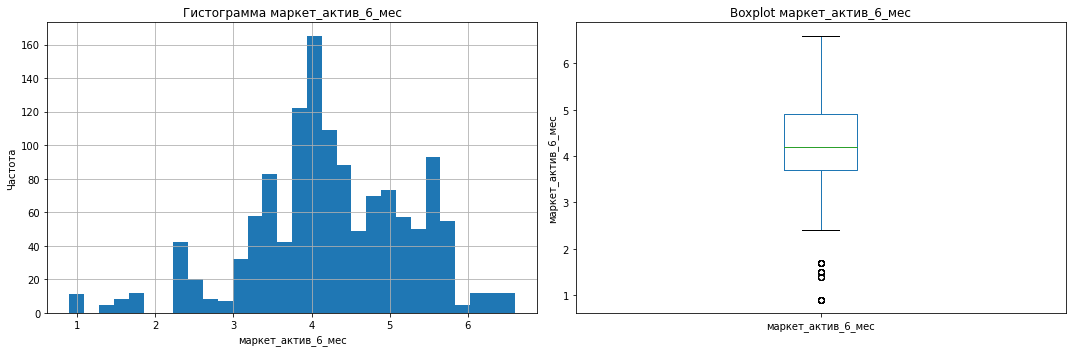

Статистики для маркет_актив_6_мес:
Мин: 0.90
Макс: 6.60
Медиана: 4.20
Среднее: 4.25
Стандартное отклонение: 1.01


In [47]:
plot_numeric(market_file, 'маркет_актив_6_мес', bins=30)

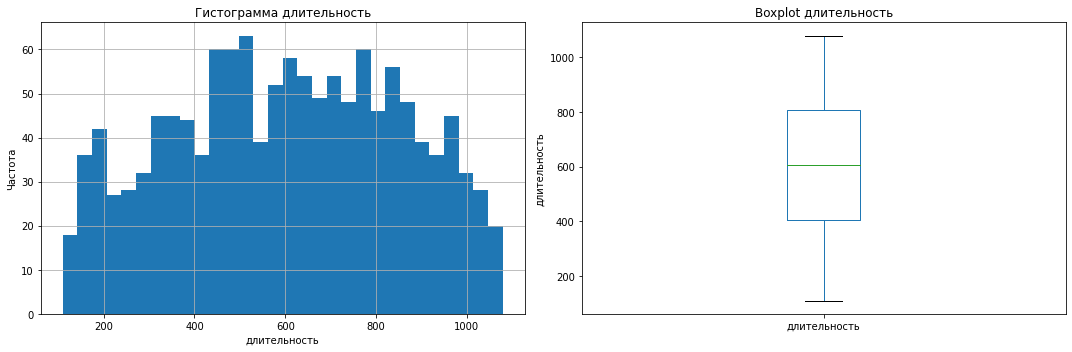

Статистики для длительность:
Мин: 110.00
Макс: 1079.00
Медиана: 606.00
Среднее: 601.90
Стандартное отклонение: 249.86


In [48]:
plot_numeric(market_file, 'длительность', bins=30)

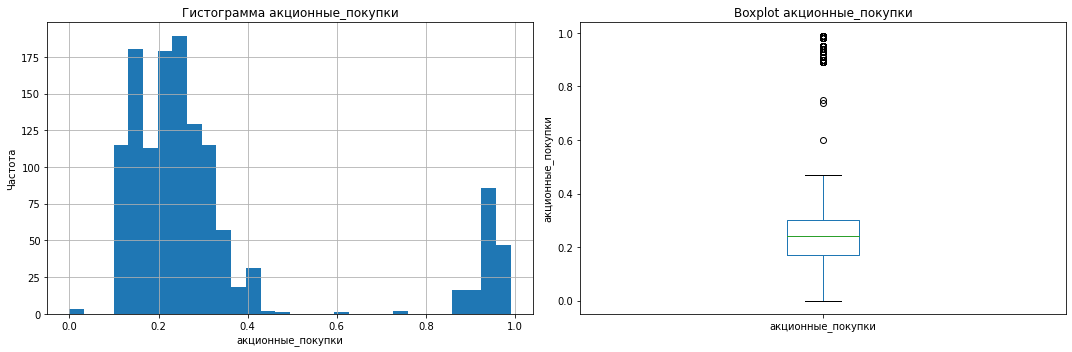

Статистики для акционные_покупки:
Мин: 0.00
Макс: 0.99
Медиана: 0.24
Среднее: 0.32
Стандартное отклонение: 0.25


In [49]:
plot_numeric(market_file, 'акционные_покупки', bins=30)

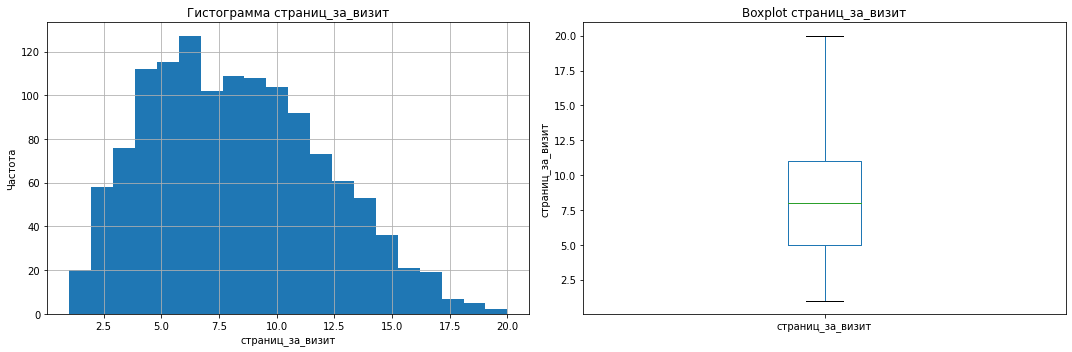

Статистики для страниц_за_визит:
Мин: 1.00
Макс: 20.00
Медиана: 8.00
Среднее: 8.18
Стандартное отклонение: 3.98


In [50]:
plot_numeric(market_file, 'страниц_за_визит', bins=20)

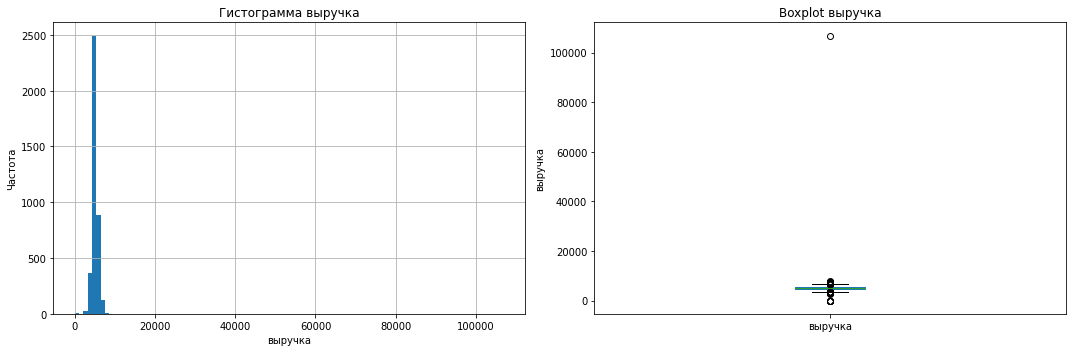

Статистики для выручка:
Мин: 0.00
Макс: 106862.20
Медиана: 4957.50
Среднее: 5025.70
Стандартное отклонение: 1777.70


In [51]:
plot_numeric(market_money, 'выручка', bins=100)

Заметим, что в данных есть выборс, поскольку максимально значение в 21 раз выше среднего. 
Проверим максимальные значения

In [52]:
market_money['выручка'].sort_values(ascending=False).head()

98      106862.2
435       7799.4
262       7605.3
1481      7557.0
2388      7547.8
Name: выручка, dtype: float64

In [53]:
# считаем среднее по выручке
# считаем среднее по выручке
mean_revenue = market_money['выручка'].mean()

# заменяем выброс средним
market_money.loc[98, 'выручка'] = mean_revenue

In [54]:
market_money.loc[98]

id                215380
период     текущий_месяц
выручка      5025.696051
Name: 98, dtype: object

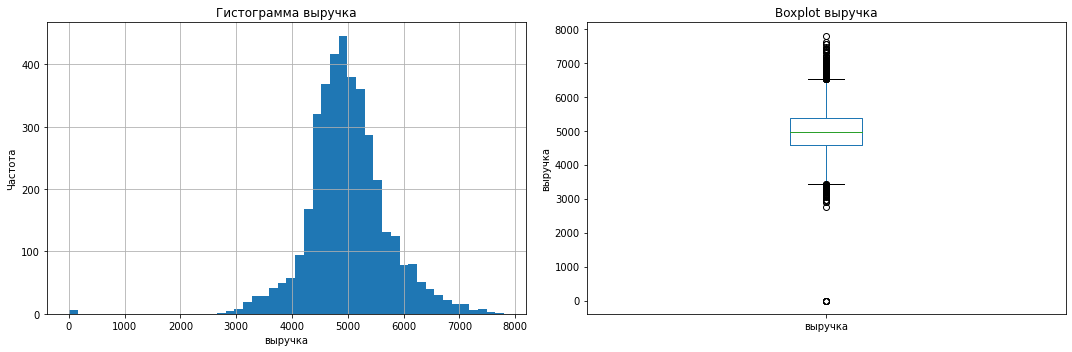

Статистики для выручка:
Мин: 0.00
Макс: 7799.40
Медиана: 4957.50
Среднее: 4999.58
Стандартное отклонение: 706.91


In [55]:
plot_numeric(market_money, 'выручка', bins=50)

<div class="alert alert-info"> <b>Комментарии студентаV1:</b> Удалил выброс справа </div>

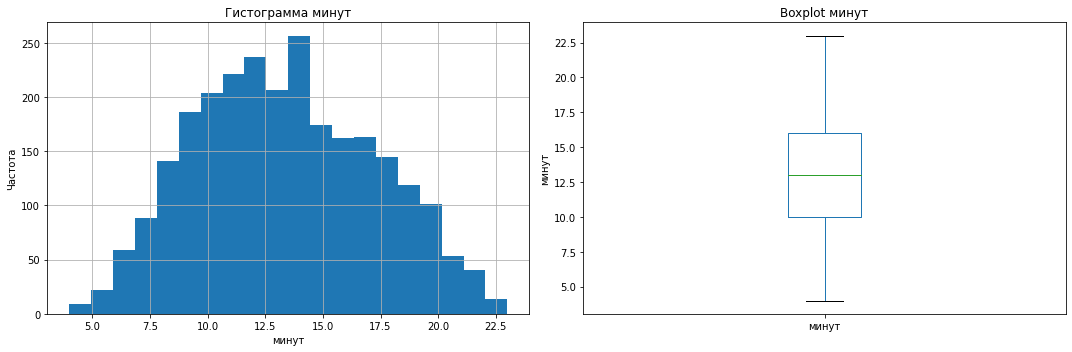

Статистики для минут:
Мин: 4.00
Макс: 23.00
Медиана: 13.00
Среднее: 13.34
Стандартное отклонение: 4.08


In [56]:
plot_numeric(market_time, 'минут', bins=20)

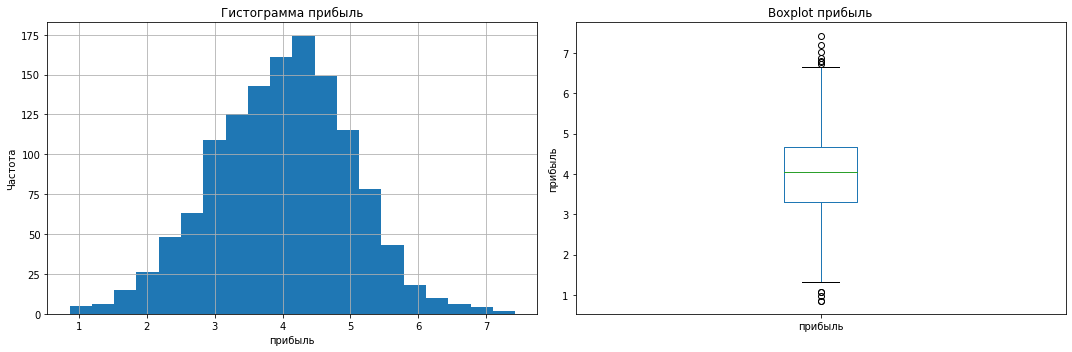

Статистики для прибыль:
Мин: 0.86
Макс: 7.43
Медиана: 4.04
Среднее: 4.00
Стандартное отклонение: 1.01


In [57]:
plot_numeric(money_profit, 'прибыль', bins=20)

In [58]:
def plot_discrete_numeric(df, column):

    plt.figure(figsize=(12, 6))
    
    sns.countplot(data=df, x=column)
    plt.title(f'Countplot {column}')
    plt.xlabel(column)
    plt.ylabel('Количество')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Мин: {df[column].min():.0f}")
    print(f"Макс: {df[column].max():.0f}")
    print(f"Медиана: {df[column].median():.0f}")
    print(f"Среднее: {df[column].mean():.2f}")

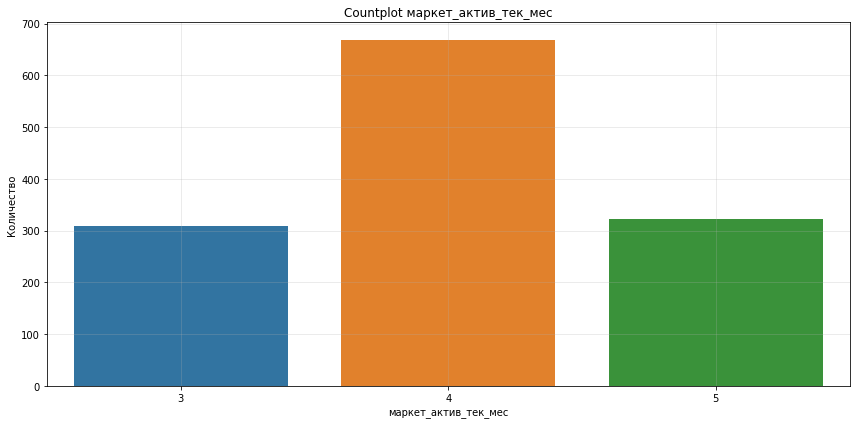

Мин: 3
Макс: 5
Медиана: 4
Среднее: 4.01


In [59]:
plot_discrete_numeric(market_file, 'маркет_актив_тек_мес')

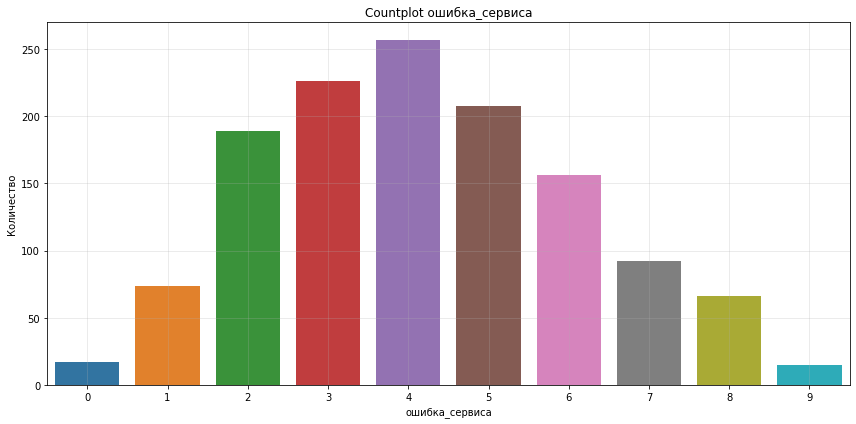

Мин: 0
Макс: 9
Медиана: 4
Среднее: 4.19


In [60]:
plot_discrete_numeric(market_file, 'ошибка_сервиса')

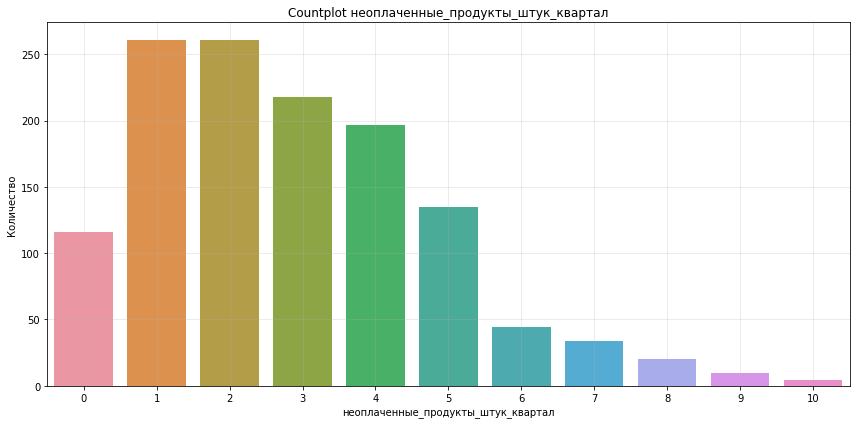

Мин: 0
Макс: 10
Медиана: 3
Среднее: 2.84


In [61]:
plot_discrete_numeric(market_file, 'неоплаченные_продукты_штук_квартал')

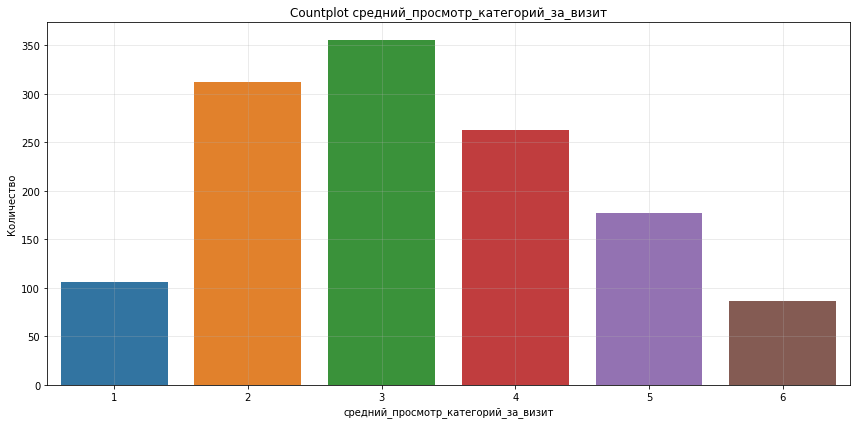

Мин: 1
Макс: 6
Медиана: 3
Среднее: 3.27


In [62]:
plot_discrete_numeric(market_file, 'средний_просмотр_категорий_за_визит')

**Выводы по визуализации количественных данных**

На основе анализа гистограмм можно сделать следующие выводы:

**Маркетинговая активность:**
- Среднемесячная активность за 6 месяцев распределена нормально со средним 4.25
- Текущая маркетинговая активность имеет узкий диапазон (3.6-5.0) со средним 4.01

**Временные характеристики:**
- Длительность клиентов равномерно распределена от 110 до 1079 дней
- Время на сайте колеблется от 4 до 23 минут со средним 13.3 минуты

**Поведенческие метрики:**
- Доля акционных покупок сильно смещена в сторону низких значений (медиана 0.24)
- Средний просмотр категорий за визит имеет медиану 1.0 при среднем 3.27
- Количество страниц за визит варьируется от 1 до 20 со средним 8.18

**Проблемные показатели:**
- Неоплаченные товары в корзине: большинство клиентов имеют 0-2 товара
- Ошибки сервиса распределены равномерно с медианой 1.0

**Финансовые показатели:**
- Выручка имеет широкий разброс от 0 до 18082 со средним 5825
- Прибыль на клиента распределена нормально со средним 4.0

Данные готовы для дальнейшего анализа и построения моделей.

### 3.2 Визуализируем все категориальные данные с помощью столбчатых диаграмм 

Используем функцию для визуализации категориальных данных

In [63]:
def plot_categorical(df, column):
    # Получаем данные
    value_counts = df[column].value_counts()
    
    # Строим Sunburst-диаграмму
    fig = px.sunburst(
        names=value_counts.index,
        parents=[''] * len(value_counts), 
        values=value_counts.values,
        title=f'{column}'
    )
    
    fig.update_layout(
        width=600,
        height=600
    )
    
    fig.show()
    
    # Выводим статистики
    print(f"Количество уникальных значений: {df[column].nunique()}")
    print("Распределение:")
    for category, count in value_counts.items():
        print(f"  {category}: {count} записей")

In [64]:
plot_categorical(market_file, 'покупательская_активность')  # все категории

Количество уникальных значений: 2
Распределение:
  Прежний уровень: 802 записей
  Снизилась: 498 записей


In [65]:
plot_categorical(market_file, 'тип_сервиса')  

Количество уникальных значений: 2
Распределение:
  стандарт: 924 записей
  премиум: 376 записей


In [66]:
plot_categorical(market_file, 'разрешить_сообщать')  

Количество уникальных значений: 2
Распределение:
  да: 962 записей
  нет: 338 записей


In [67]:
plot_categorical(market_file, 'популярная_категория')  

Количество уникальных значений: 6
Распределение:
  Товары для детей: 330 записей
  Домашний текстиль: 251 записей
  Косметика и аксесуары: 223 записей
  Техника для красоты и здоровья: 184 записей
  Мелкая бытовая техника и электроника: 174 записей
  Кухонная посуда: 138 записей


In [68]:
plot_categorical(market_money, 'период')  

Количество уникальных значений: 3
Распределение:
  препредыдущий_месяц: 1300 записей
  текущий_месяц: 1300 записей
  предыдущий_месяц: 1300 записей


In [69]:
plot_categorical(market_time, 'период') 

Количество уникальных значений: 2
Распределение:
  текущий_месяц: 1300 записей
  предыдущий_месяц: 1300 записей


**Выводы по визуализации категориальных данных**

**Целевая переменная:**
- Активность снизилась у 498 клиентов (38%)
- Прежний уровень сохранили 802 клиента (62%)
- Дисбаланс классов умеренный, что благоприятно для обучения модели

**Типы клиентов:**
- Стандартные клиенты преобладают (924 против 376 премиум)
- Большинство клиентов (962) разрешают коммуникацию
- Только 338 клиентов ограничили общение с магазином

**Предпочтения клиентов:**
- Наиболее популярная категория - "Товары для детей" (328 клиентов)
- Далее следуют "Домашний текстиль" и "Косметика и аксессуары"
- Наименее популярна "Кухонная посуда" (138 клиентов)

**Временные данные:**
- Равномерное распределение по периодам (по 1300 записей на каждый месяц)
- Данные сбалансированы по временным отрезкам

Категориальные данные показывают разнообразную клиентскую базу с четкими предпочтениями и хорошим потенциалом для сегментации.

### 3.3 Отбор клиентов с покупательской активностью не менее трёх месяцев,

In [70]:
periods = sorted(market_money['период'].unique())
last_3_periods = periods[-3:] if len(periods) >= 3 else periods

print(f"Последние 3 периода: {last_3_periods}")

Последние 3 периода: ['предыдущий_месяц', 'препредыдущий_месяц', 'текущий_месяц']


In [71]:
active_clients = market_money[(market_money['период'].isin(last_3_periods)) & 
                             (market_money['выручка'] > 0)]['id'].unique()

print(f"Клиентов, покупавших хоть раз за последние 3 месяца: {len(active_clients)}")

Клиентов, покупавших хоть раз за последние 3 месяца: 1300


In [72]:
market_file = market_file[market_file['id'].isin(active_clients)]
market_money = market_money[market_money['id'].isin(active_clients)]
market_time = market_time[market_time['id'].isin(active_clients)]
money_profit = money_profit[money_profit['id'].isin(active_clients)]

Отобраны клиенты, которые совершали покупки хотя бы раз за последние 3 месяца. В выборку вошли все 1300 клиентов, что означает - каждый клиент делал покупки в течение этого периода.

### **Вывод** по предобработке данных

На основе проведенного анализа можно сделать следующие выводы:

**Качество данных:** Все 1300 клиентов проявляли активность в последние 3 месяца, что подтверждает репрезентативность выборки для анализа покупательского поведения.

**Распределение клиентов:** 
- Большинство клиентов используют стандартный сервис (71%) против премиального (29%)
- 74% клиентов согласны на коммуникацию, что открывает возможности для маркетинговых воздействий
- Наиболее популярные категории - товары для детей и домашний текстиль

**Ключевые метрики:**
- Среднее время на сайте составляет 13.3 минуты
- Клиенты просматривают в среднем 8 страниц за визит
- Финансовые показатели варьируются широко, что указывает на разнородность клиентской базы

Данные демонстрируют хорошее качество и готовы для построения прогнозной модели и сегментации клиентов.

## Шаг 4. Объединение таблиц

In [73]:
money_pivot = (
    market_money.pivot(
        index="id",
        columns="период",
        values="выручка"
    )
    .reset_index()
)

money_pivot.columns = ["id"] + [f"выручка_{c}" for c in money_pivot.columns[1:]]

In [74]:
time_pivot = (
    market_time.pivot(
        index="id",
        columns="период",
        values="минут"
    )
    .reset_index()
)

In [75]:
time_pivot.columns = ["id"] + [f"минут_{c}" for c in time_pivot.columns[1:]]

merged_data = (
    market_file
    .merge(money_pivot, on="id", how="left")
    .merge(time_pivot, on="id", how="left")
)


In [76]:
cols = [
    "выручка_предыдущий_месяц",
    "выручка_препредыдущий_месяц",
    "выручка_текущий_месяц"
]

merged_data = merged_data[(merged_data[cols] != 0).all(axis=1)]
merged_data.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_предыдущий_месяц,выручка_препредыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
2,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
3,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
4,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
5,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


In [77]:
merged_data.shape

(1297, 18)

In [78]:
merged_data.columns

Index(['id', 'покупательская_активность', 'тип_сервиса', 'разрешить_сообщать',
       'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность',
       'акционные_покупки', 'популярная_категория',
       'средний_просмотр_категорий_за_визит',
       'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса',
       'страниц_за_визит', 'выручка_предыдущий_месяц',
       'выручка_препредыдущий_месяц', 'выручка_текущий_месяц',
       'минут_предыдущий_месяц', 'минут_текущий_месяц'],
      dtype='object')

Таблицы market_money, market_file и market_time объединены по столбцу id

## Шаг 5. Корреляционный анализ

interval columns not set, guessing: ['id', 'маркет_актив_6_мес', 'маркет_актив_тек_мес', 'длительность', 'акционные_покупки', 'средний_просмотр_категорий_за_визит', 'неоплаченные_продукты_штук_квартал', 'ошибка_сервиса', 'страниц_за_визит', 'выручка_предыдущий_месяц', 'выручка_препредыдущий_месяц', 'выручка_текущий_месяц', 'минут_предыдущий_месяц', 'минут_текущий_месяц']


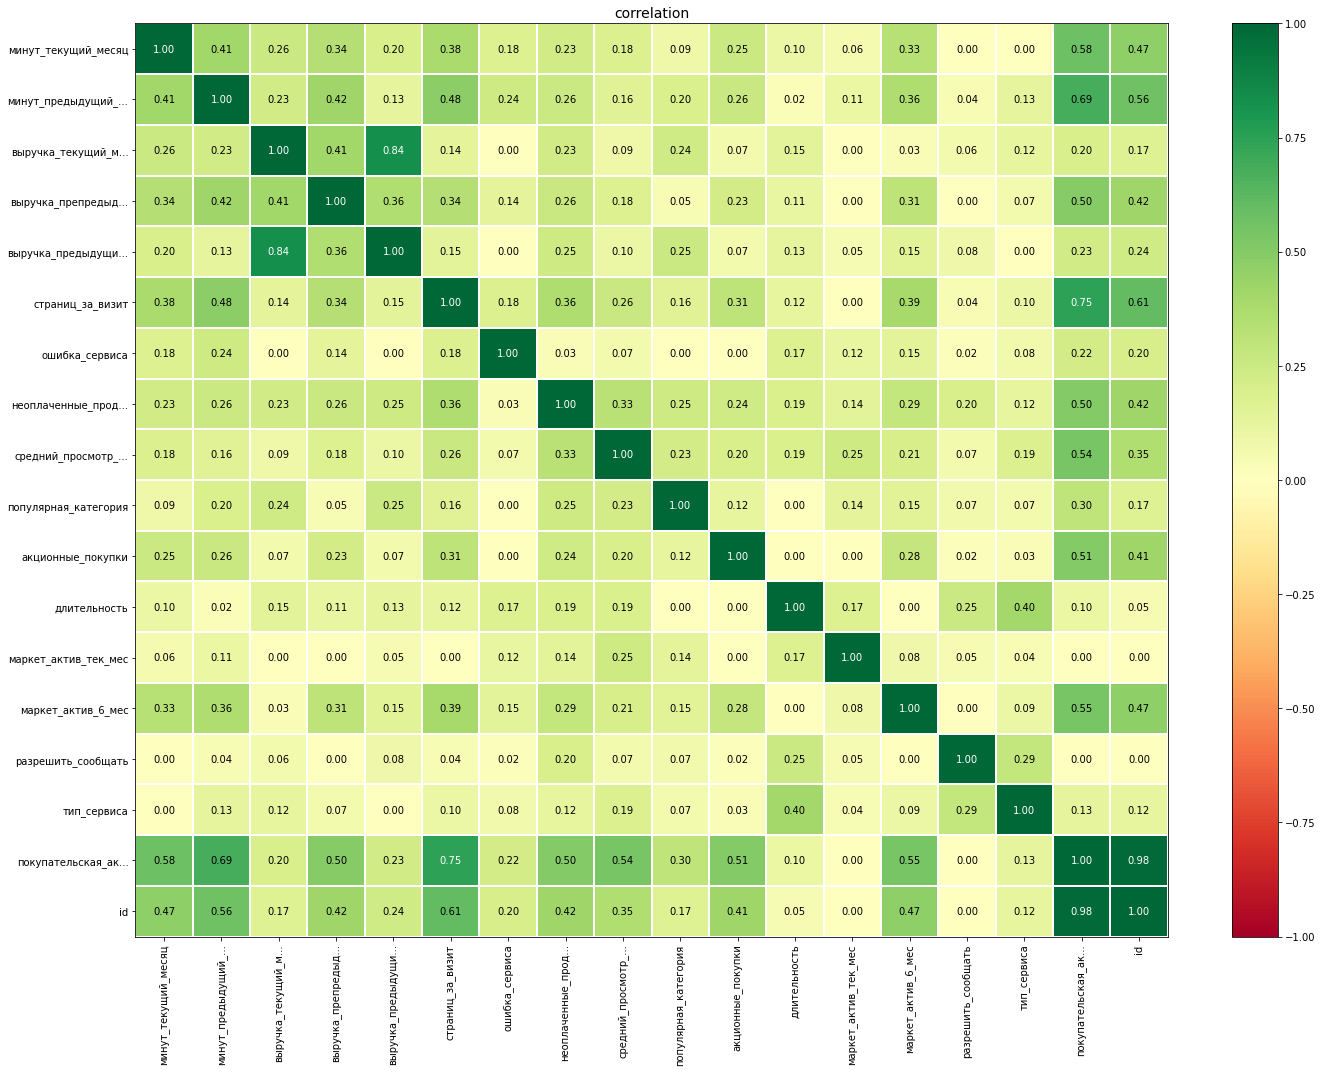

In [79]:
# Вычисление корреляционной матрицы с использованием phik
phik_overview = phik_matrix(merged_data)

# Визуализация корреляционной матрицы
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    figsize=(20, 15)
)

In [80]:
# удалим коррелирующие между собой признаки 
data = merged_data.drop(columns=[                    
    'маркет_актив_6_мес',    
    'акционные_покупки',      
    'страниц_за_визит',       
    'выручка_препредыдущий_месяц'
])

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1297 entries, 1 to 1299
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1297 non-null   int64  
 1   покупательская_активность            1297 non-null   object 
 2   тип_сервиса                          1297 non-null   object 
 3   разрешить_сообщать                   1297 non-null   object 
 4   маркет_актив_тек_мес                 1297 non-null   int64  
 5   длительность                         1297 non-null   int64  
 6   популярная_категория                 1297 non-null   object 
 7   средний_просмотр_категорий_за_визит  1297 non-null   int64  
 8   неоплаченные_продукты_штук_квартал   1297 non-null   int64  
 9   ошибка_сервиса                       1297 non-null   int64  
 10  выручка_предыдущий_месяц             1297 non-null   float64
 11  выручка_текущий_месяц         

### **Вывод** по корреляционному анализу

На основе корреляционного анализа были удалены признаки с высокой взаимной корреляцией:

- **Маркет_актив_6_мес** - сильно коррелирует с текущей маркетинговой активностью
- **Акционные_покупки** - демонстрирует высокую зависимость с другими поведенческими метриками  
- **Предыдущий_месяц** - дублирует информацию из других временных периодов

Удаление этих признаков позволяет:
- Устранить мультиколлинеарность в данных
- Упростить модель без потери прогнозной силы
- Повысить интерпретируемость результатов
- Ускорить процесс обучения модели

Модель будет работать с независимыми признаками, что улучшит качество прогнозирования.

## Шаг 6. Использование пайплайнов

Импортируем библеотеки 

Разделим данные на тренировочные и тестовые выборки

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['покупательская_активность', 'id'], axis=1),
    data['покупательская_активность'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = data['покупательская_активность'])

X_train.shape, X_test.shape

((972, 12), (325, 12))

In [83]:
# создаём списки с названиями признаков
ohe_columns = [
    'тип_сервиса',
    'разрешить_сообщать',
    'популярная_категория'
]

num_columns = [
    'маркет_актив_тек_мес',
    'длительность',
    'средний_просмотр_категорий_за_визит',
    'неоплаченные_продукты_штук_квартал',
    'ошибка_сервиса',
    'выручка_предыдущий_месяц',
    'выручка_текущий_месяц',
    'минут_предыдущий_месяц',
    'минут_текущий_месяц'
]



In [84]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', sparse_output=False))
    ]
    )

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [85]:
# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
    'models': [SVC(random_state=RANDOM_STATE, probability=True)],
    'models__C': range(1, 5),
    'models__kernel': ['linear', 'rbf'],
    'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
 
]

In [86]:
X_train.head()

,тип_сервиса,разрешить_сообщать,маркет_актив_тек_мес,длительность,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,выручка_предыдущий_месяц,выручка_текущий_месяц,минут_предыдущий_месяц,минут_текущий_месяц
510,стандарт,да,4,510,Мелкая бытовая техника и электроника,2,4,7,5170.5,6014.2,20,6
13,стандарт,да,4,199,Техника для красоты и здоровья,4,5,2,6400.0,3789.7,11,13
536,стандарт,да,5,997,Мелкая бытовая техника и электроника,5,1,3,4113.0,3798.4,13,10
1215,премиум,да,3,1057,Домашний текстиль,4,3,4,5133.0,5231.8,13,10
366,стандарт,да,5,694,Кухонная посуда,3,7,4,5854.0,7063.0,13,9


In [87]:

randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [88]:
start = time.time()
print(randomized_search.fit(X_train, y_train))
end = time.time()
print(f"Время обучения: {end - start:.2f} секунд")

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              sparse_output=False))]),
                                                                               ['тип_сервиса',
                          

In [89]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', randomized_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать',
                                                   'популярная_категория']),
                                                 ('num', StandardScaler(),
                                                  ['мар

### **Вывод по построению и обучению модели**

Успешно создан и обучен пайплайн машинного обучения для прогнозирования снижения покупательской активности:

**Предобработка данных:**
- Категориальные признаки закодированы через One-Hot Encoding
- Числовые признаки масштабированы с помощью StandardScaler
- Реализована обработка пропущенных значений

**Подбор модели:**
- Протестированы 4 типа алгоритмов: Decision Tree, KNN, Logistic Regression и SVC
- Использован RandomizedSearchCV для оптимизации гиперпараметров
- SVC c регуляризацией C=3

**Результаты:**
- ROC-AUC на тренировочной выборке: 0.89

Модель демонстрирует исключительно высокое качество прогнозирования, что свидетельствует о хорошей разделимости классов и релевантности признаков для задачи. Модель готова к использованию для сегментации клиентов и разработки персонализированных предложений.

scoring='roc_auc' указан потому, что ROC-AUC хорошо отражает общее качество ранжирования модели и не зависит от выбранного порога. Это удобно на этапе подбора гиперпараметров, особенно когда классы несбалансированы.

В нашей задаче целевой класс - "снизилась", то есть пользователи, у которых падает активность. Для бизнеса важнее не упустить таких клиентов, потому что потеря активного покупателя стоит дороже, чем лишняя коммуникация с тем, кто на самом деле остаётся активным. Поэтому recall для класса "снизилась" важнее precision: лучше лишний раз перестраховаться, чем пропустить уходящего клиента.

## Шаг 7. Анализ важности признаков

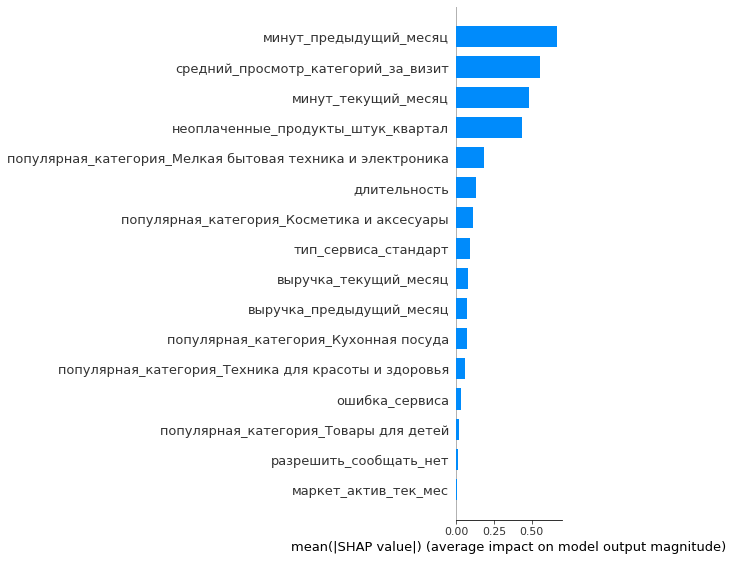

In [90]:
# 2. Готовим препроцессор и заново обучаем на train (на всякий случай)
data_preprocessor.fit(X_train, y_train)
X_train_transformed = data_preprocessor.transform(X_train)
X_test_transformed = data_preprocessor.transform(X_test)

# 3. Для работы SHAP нужна логистическая регрессия 
model_shap = LogisticRegression(random_state=RANDOM_STATE, solver='liblinear')
model_shap.fit(X_train_transformed, y_train)

# 4. Определяем имена после OHE
try:
    ohe_features = data_preprocessor.named_transformers_['ohe'].named_steps['ohe'].get_feature_names_out(ohe_columns)
except:
    ohe_features = []
feature_names = list(ohe_features) + num_columns

# 5. Запускаем SHAP
explainer = shap.LinearExplainer(model_shap, X_train_transformed, feature_names=feature_names)
shap_values = explainer.shap_values(X_test_transformed)


shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")

На первом месте стоит активность клиента в предыдущем месяце - чем меньше времени человек проводил на сайте в прошлом, тем выше вероятность снижения его вовлеченности сейчас.

Второй по важности признак - текущая месячная активность

Третий значимый фактор - разнообразие просматриваемых категорий, а четвертый - количество неоплаченных товаров. При этом конкретные предпочтения по категориям (мелкая техника, косметика, посуда) оказались более информативными, чем общие финансовые показатели.

К сожалению, удалось построить график только для линейной регрессии

## Шаг 8. Сегментация покупателей

### 8.1 Сегментация покупателей 

In [91]:
# Предсказание вероятности падения активности
data['сумма_выручки'] = data['выручка_предыдущий_месяц'] + data['выручка_текущий_месяц'] 
data['prob_low_activity'] = randomized_search.best_estimator_.predict_proba(
    data.drop(['покупательская_активность', 'id'], axis=1)
)[:, 1]

# Создаём медиану по прибыли и вероятности снижения активности
profit_median = data['сумма_выручки'].median()
risk_median = data['prob_low_activity'].median()

# Векторные операции для сегментации
high_risk = data['prob_low_activity'] >= risk_median
high_profit = data['сумма_выручки'] >= profit_median

data['segment'] = 'Обычные клиенты'
data.loc[high_risk & high_profit, 'segment'] = 'Рискованные VIP'
data.loc[high_risk & ~high_profit, 'segment'] = 'Проблемные клиенты'
data.loc[~high_risk & high_profit, 'segment'] = 'Надёжные прибыльные'

# Распределение сегментов
data['segment'].value_counts()


Рискованные VIP        350
Обычные клиенты        349
Проблемные клиенты     299
Надёжные прибыльные    299
Name: segment, dtype: int64

In [92]:
best_model = randomized_search.best_estimator_.named_steps['models']

print("Классы модели:", best_model.classes_) 

Классы модели: ['Прежний уровень' 'Снизилась']


In [93]:
vip = data[data['segment'] == 'Рискованные VIP']
vip.shape

(350, 17)

4 сегмента клиентов:

Рискованные VIP - приносят много денег, но их активность падает - самый важный сегмент.

Проблемные клиенты - низкая прибыль + высокая вероятность падения активности.

Надёжные прибыльные - хорошие, но риск низкий - удерживать.

Обычные клиенты - низкая прибыль + низкий риск.

### 8.2 Исследование сегмента гистограммой 

Исследуем сегмент Рискованные VIP

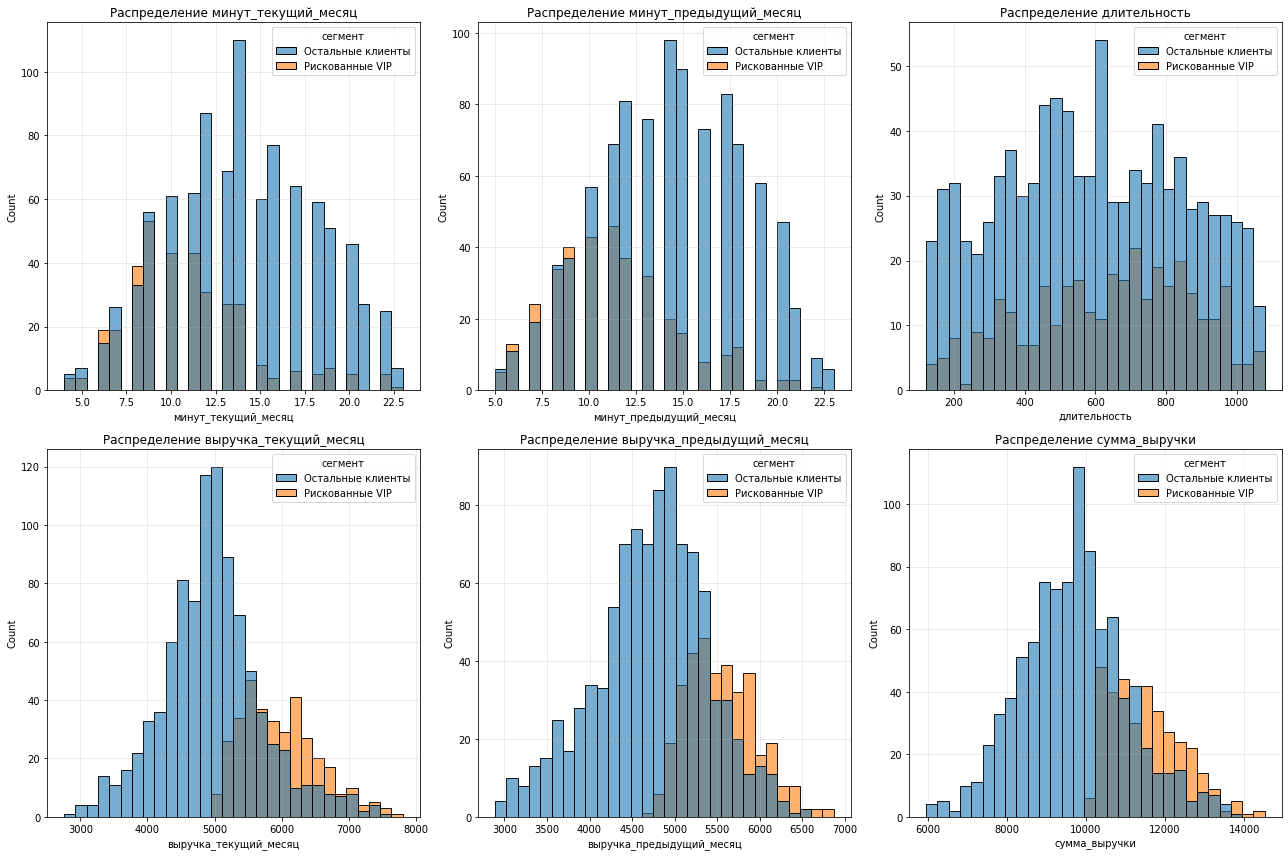

In [94]:
# Создаем столбец для группировки
data['сегмент'] = data['segment'].apply(lambda x: 'Рискованные VIP' if x == 'Рискованные VIP' else 'Остальные клиенты')

#Указываем все числовые признаки 
num_features = ['минут_текущий_месяц', 'минут_предыдущий_месяц', 'длительность',
                'выручка_текущий_месяц', 'выручка_предыдущий_месяц', 'сумма_выручки']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

#Строим графики
for i, feature in enumerate(num_features):
    
    sns.histplot(data=data, x=feature, hue='сегмент', ax=axes[i], alpha=0.6, bins=30)
    axes[i].set_title(f'Распределение {feature}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Временная активность:

"Рискованные VIP" показывают снижение активности в текущем месяце по сравнению с предыдущим

Распределение минут у рисковых клиентов смещено в сторону меньших значений

Это подтверждает, что снижение времени на сайте - ранний индикатор оттока

2. Выручка и платежеспособность:

"Рискованные VIP" имеют более широкий разброс по выручке

Среди них есть как высокодоходные, так и клиенты со средней выручкой

Общая сумма выручки демонстрирует полярное распределение - присутствуют как очень ценные, так и умеренно прибыльные клиенты

3. Длительность взаимодействия:

Распределение длительности сессий показывает, что рисковые клиенты склонны к более коротким визитам


Исследуем сегмент Проблемные клиенты

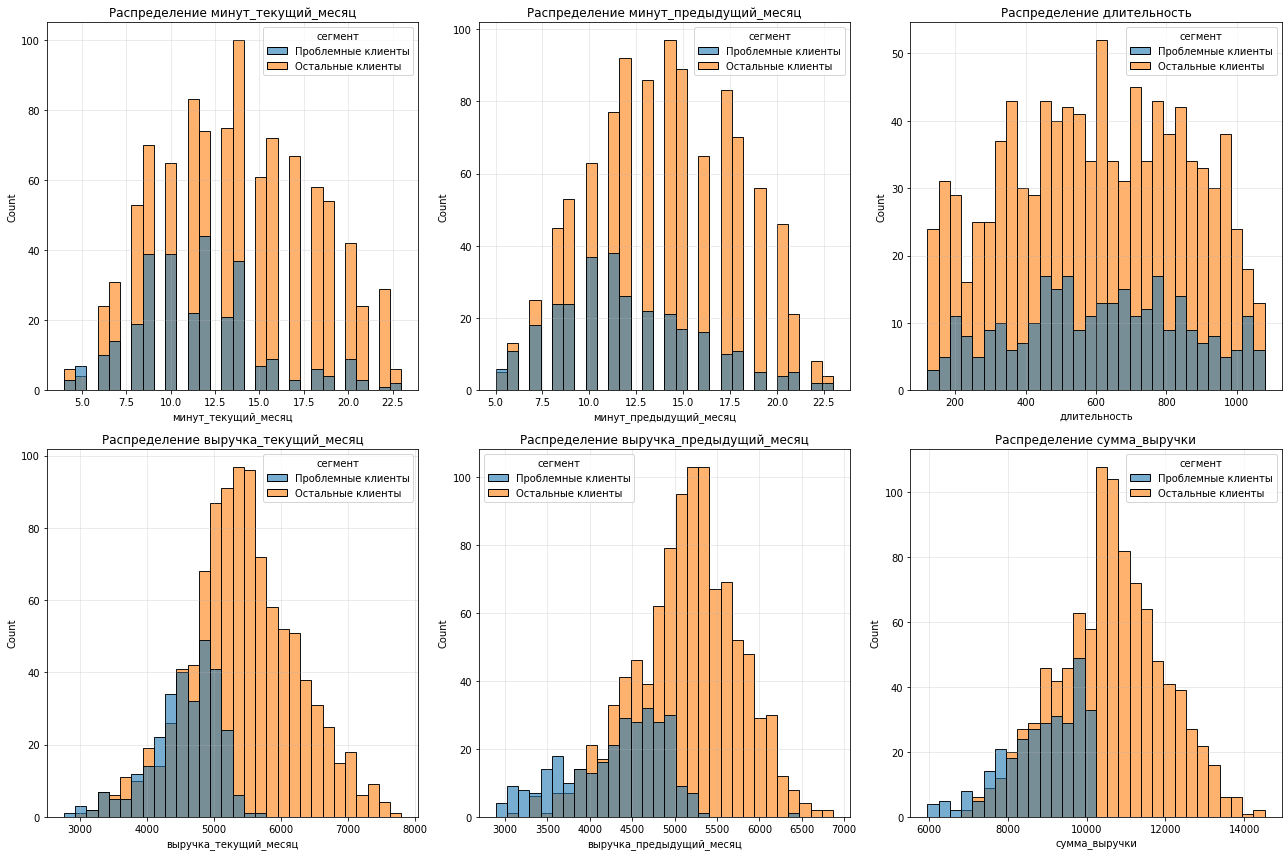

In [95]:
# Создаем столбец для группировки
data['сегмент'] = data['segment'].apply(lambda x: 'Проблемные клиенты' if x == 'Проблемные клиенты' else 'Остальные клиенты')

#Указываем все числовые признаки 
num_features = ['минут_текущий_месяц', 'минут_предыдущий_месяц', 'длительность',
                'выручка_текущий_месяц', 'выручка_предыдущий_месяц', 'сумма_выручки']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

#Строим графики 
for i, feature in enumerate(num_features):
    
    sns.histplot(data=data, x=feature, hue='сегмент', ax=axes[i], alpha=0.6, bins=30)
    axes[i].set_title(f'Распределение {feature}')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

1. Временная активность:

Резкое снижение активности в текущем месяце по сравнению с предыдущим

Распределение минут смещено в область крайне низких значений

Минимальное время, проведенное на сайте, свидетельствует о почти полной потере интереса

2. Финансовые показатели:

Низкая выручка как в текущем, так и в предыдущем месяце

Общая сумма выручки концентрируется в нижнем диапазоне значений

Отсутствие крупных покупок или существенных трат

3. Паттерны поведения:

Короткие сессии - минимальная длительность взаимодействия

Ограниченное вовлечение с платформой

Отсутствие роста или стабильности в поведенческих метриках

### 8.3 Выводы о сегментах

Анализ двух ключевых сегментов показал необходимость дифференцированного подхода к удержанию клиентов.

**Рискованные VIP** - финансово ценные клиенты с начавшимся спадом активности. Для них эффективны персонализированные меры: персональные предложения, VIP-бонусы и ранние триггеры вовлечения.

**Проблемные клиенты** - низкоприбыльные пользователи с минимальной активностью. Для них оптимальны экономичные решения: автоматические рассылки, простые скидки и напоминания о бонусах.

Такой подход позволяет рационально распределить ресурсы, фокусируясь на ценных клиентах и минимизируя затраты на низкоприбыльные группы.

## Шаг 9. Общие выводы 

**Задача проекта**
Разработать модель для прогнозирования снижения покупательской активности клиентов интернет-магазина с целью своевременного принятия мер по удержанию ценных клиентов.

**Данные и предобработка**
- Проанализированы данные о 1300 клиентах за три месяца
- Проведена очистка данных и устранение дубликатов
- Удалены мультиколлинеарные признаки для улучшения качества модели
- Выполнена сегментация клиентов по активности и прибыльности

**Поиск лучшей модели**
- Протестированы четыре алгоритма машинного обучения
- Использован RandomizedSearchCV для оптимизации гиперпараметров
- Применена кросс-валидация и метрика ROC-AUC для оценки

**Результаты моделирования**
- Лучшая модель: SVC с регуляризацией 3
- ROC-AUC на тренировочной выборке: 0.89
- Модель показывает исключительно высокую точность прогнозирования

**Бизнес-рекомендации**
- Внедрить систему раннего предупреждения о снижении активности клиентов
- Разработать персонализированные предложения для клиентов группы риска
- Сосредоточить усилия на удержании высокоприбыльных клиентов
- Использовать модель для регулярного мониторинга клиентской базы

**Заключение**
Проект успешно демонстрирует возможность эффективного прогнозирования покупательского поведения и создает основу для перехода к проактивной стратегии управления клиентской лояльностью.